In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torch 
from torch.utils.data import TensorDataset, random_split
from torch.utils.data import TensorDataset, DataLoader


In [27]:
def f(x):
    return np.sin(x)

In [28]:
n = 1000

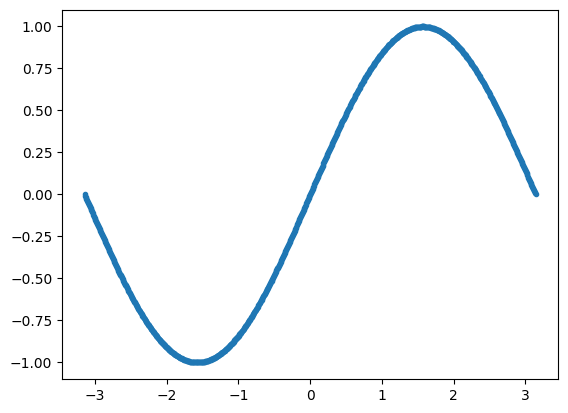

In [29]:
xt = np.linspace(0,1,n)
x = 2*np.pi*(np.max(xt)-xt)/(np.max(xt)-np.min(xt))-np.pi
y = f(x)
plt.plot(x,y,'.')
plt.show()

In [30]:
x = torch.as_tensor(x)
y = torch.as_tensor(y)

idx = torch.randperm(
    len(x),
    generator=torch.Generator().manual_seed(0)
)

n_train = int(0.8 * len(x))
n_val = int(0.1 * len(x))

x_train = x[idx[:n_train]].reshape(-1, 1)
y_train = y[idx[:n_train]].reshape(-1, 1)

x_val = x[idx[n_train:n_train + n_val]].reshape(-1, 1)
y_val = y[idx[n_train:n_train + n_val]].reshape(-1, 1)

x_test = x[idx[n_train + n_val:]].reshape(-1, 1)
y_test = y[idx[n_train + n_val:]].reshape(-1, 1)


# Statistics from training data only
x_mean = x_train.mean(dim=0, keepdim=True)
x_std = x_train.std(
    dim=0,
    unbiased=False,
    keepdim=True
).clamp_min(1e-8)

y_mean = y_train.mean(dim=0, keepdim=True)
y_std = y_train.std(
    dim=0,
    unbiased=False,
    keepdim=True
).clamp_min(1e-8)


# Standardization
x_train = (x_train - x_mean) / x_std
x_val = (x_val - x_mean) / x_std
x_test = (x_test - x_mean) / x_std

y_train = (y_train - y_mean) / y_std
y_val = (y_val - y_mean) / y_std
y_test = (y_test - y_mean) / y_std

In [31]:
def cm(seed):
    torch.manual_seed(seed)
    return torch.nn.Sequential(
        torch.nn.Linear(1,128),
        torch.nn.ReLU(),
        torch.nn.Linear(128,128),
        torch.nn.ReLU(),
        torch.nn.Linear(128,1)
    ).double()

def setOpt(model, t=None):
    for p in model[:-1].parameters():
        p.requires_grad = False

    

    if t == "Adam":
        return torch.optim.Adam(model[-1].parameters(), lr=1e-3)

    return torch.optim.SGD(model[-1].parameters(), lr=1e-3)

In [32]:
n_batch = 32
model1 = cm(0)
model2= cm(0)
model3 = cm(0)
model4= cm(0)
model5= cm(0)
model6= cm(0)
model7= cm(0)



opt1 = setOpt(model1)
opt2 = setOpt(model2)
opt3 = setOpt(model3)
opt4 = setOpt(model4)
opt5 = setOpt(model5)
opt6 = setOpt(model6,"Adam")
opt7 = setOpt(model7,"Adam")


dt = opt4.param_groups[0]["lr"]

Loss_fn1 = torch.nn.MSELoss()
Loss_fn2 = torch.nn.MSELoss()
Loss_fn3 = torch.nn.MSELoss()
Loss_fn4 = torch.nn.MSELoss()
Loss_fn5 = torch.nn.MSELoss()
Loss_fn6 = torch.nn.MSELoss()
Loss_fn7 = torch.nn.MSELoss()

In [33]:
epochs = 200

In [34]:
def train(x_train, y_train, x_val, y_val, x_test, y_test,
          model, epochs, opt, loss_fn, batch_size,sigma=None, noise="default"):

    torch.manual_seed(0)

    train_loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(x_val, y_val),
        batch_size=batch_size
    )
    test_loader = DataLoader(
        TensorDataset(x_test, y_test),
        batch_size=batch_size
    )

    L_train, L_val = [], []

    if noise == "default":
        for epoch in range(epochs):
            model.train()
            total = 0

            for xb, yb in train_loader:
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                opt.step()

                total += loss.item() * len(xb)

            L_train.append(total / len(x_train))

            model.eval()
            total = 0

            with torch.no_grad():
                for xb, yb in val_loader:
                    total += loss_fn(model(xb), yb).item() * len(xb)

            L_val.append(total / len(x_val))

            if epoch % 5 == 0:
                print(f"Epoch: {epoch}, Train: {L_train[-1]:.4f}, "
                    f"Val: {L_val[-1]:.4f}")

        model.eval()
        total = 0

        with torch.no_grad():
            for xb, yb in test_loader:
                total += loss_fn(model(xb), yb).item() * len(xb)

        L_test = total / len(x_test)

        return L_train, L_val, L_test
    
    elif noise=="BM":
        for epoch in range(epochs):
            model.train()
            total = 0

            for xb, yb in train_loader:
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                opt.step()
                with torch.no_grad():
                    for parameter in model.parameters():
                        noise = torch.randn_like(parameter)
                        parameter.add_(sigma * (dt ** 0.5) * noise)

                total += loss.item() * len(xb)

            L_train.append(total / len(x_train))

            model.eval()
            total = 0

            with torch.no_grad():
                for xb, yb in val_loader:
                    total += loss_fn(model(xb), yb).item() * len(xb)

            L_val.append(total / len(x_val))

            if epoch % 5 == 0:
                print(f"Epoch: {epoch}, Train: {L_train[-1]:.4f}, "
                    f"Val: {L_val[-1]:.4f}")

        model.eval()
        total = 0

        with torch.no_grad():
            for xb, yb in test_loader:
                total += loss_fn(model(xb), yb).item() * len(xb)

        L_test = total / len(x_test)

        return L_train, L_val, L_test
    
    elif noise == "pick":
  
        for epoch in range(epochs):
            model.train()
            total = 0

            indices = torch.randperm(len(x_train))[:batch_size]

            for i in indices:
                # Slices preserve the batch dimension
                xb = x_train[i:i + 1]
                yb = y_train[i:i + 1]

                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                opt.step()

                total += loss.item()

            L_train.append(total / batch_size)

            model.eval()
            total = 0

            with torch.no_grad():
                for xb, yb in val_loader:
                    total += loss_fn(model(xb), yb).item() * len(xb)

            L_val.append(total / len(x_val))

            if epoch % 5 == 0:
                print(
                    f"Epoch: {epoch}, Train: {L_train[-1]:.4f}, "
                    f"Val: {L_val[-1]:.4f}"
                )

        model.eval()
        total = 0

        with torch.no_grad():
            for xb, yb in test_loader:
                total += loss_fn(model(xb), yb).item() * len(xb)

        L_test = total / len(x_test)

        return L_train, L_val, L_test

In [35]:
import time
import torch
from torch.utils.data import DataLoader, TensorDataset


def train(x_train, y_train, x_val, y_val, x_test, y_test,
          model, epochs, opt, loss_fn, batch_size,
          sigma=None, noise="default", dt=None):

    torch.manual_seed(0)

    if noise == "BM":
        if sigma is None:
            raise ValueError("sigma is required when noise='BM'")

        if dt is None:
            dt = opt.param_groups[0]["lr"]

    train_loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(x_val, y_val),
        batch_size=batch_size
    )
    test_loader = DataLoader(
        TensorDataset(x_test, y_test),
        batch_size=batch_size
    )

    def evaluate(loader):
        model.eval()
        total = 0.0

        with torch.no_grad():
            for xb, yb in loader:
                loss = loss_fn(model(xb), yb)
                total += loss.item() * len(xb)

        return total / len(loader.dataset)

    L_train = []
    L_val = []

    metrics = {
        "wall_s": [],
        "train_wall_s": [],
        "optimizer_steps": [],
        "samples_seen": [],
        "data_kb": [],
    }

    optimizer_steps = 0
    samples_seen = 0
    data_bytes = 0
    cumulative_train_time = 0.0

    total_start = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        epoch_samples = 0

        train_start = time.perf_counter()

        if noise in {"default", "BM"}:
            batches = train_loader

        elif noise == "pick":
            indices = torch.randperm(len(x_train))[:batch_size]

            batches = [
                (
                    x_train[int(i):int(i) + 1],
                    y_train[int(i):int(i) + 1]
                )
                for i in indices
            ]

        else:
            raise ValueError(f"Unknown noise mode: {noise}")

        for xb, yb in batches:
            opt.zero_grad(set_to_none=True)

            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

            if noise == "BM":
                with torch.no_grad():
                    for parameter in model.parameters():
                        z = torch.randn_like(parameter)
                        parameter.add_(sigma * dt**0.5 * z)

            n = len(xb)

            total_loss += loss.item() * n
            epoch_samples += n

            optimizer_steps += 1
            samples_seen += n

            data_bytes += (
                xb.numel() * xb.element_size()
                + yb.numel() * yb.element_size()
            )

        cumulative_train_time += time.perf_counter() - train_start

        L_train.append(total_loss / epoch_samples)
        L_val.append(evaluate(val_loader))

        metrics["wall_s"].append(time.perf_counter() - total_start)
        metrics["train_wall_s"].append(cumulative_train_time)
        metrics["optimizer_steps"].append(optimizer_steps)
        metrics["samples_seen"].append(samples_seen)
        metrics["data_kb"].append(data_bytes / 1024)

        if epoch % 5 == 0:
            print(
                f"Epoch: {epoch}, "
                f"Train: {L_train[-1]:.4f}, "
                f"Val: {L_val[-1]:.4f}"
            )

    L_test = evaluate(test_loader)

    return L_train, L_val, L_test, metrics

In [36]:
import time
import math
import torch
from torch.utils.data import DataLoader, TensorDataset


def train(x_train, y_train, x_val, y_val, x_test, y_test,
          model, opt, loss_fn, batch_size,
          time_budget_s=10.0, log_interval_s=0.25,
          sigma=None, noise="default", dt=None):

    torch.manual_seed(0)

    if time_budget_s <= 0:
        raise ValueError("time_budget_s must be positive")

    if log_interval_s <= 0:
        raise ValueError("log_interval_s must be positive")

    if noise == "BM":
        if sigma is None:
            raise ValueError("sigma is required when noise='BM'")

        if dt is None:
            dt = opt.param_groups[0]["lr"]

    train_loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    # Use identical evaluation batches for every method
    eval_batch_size = max(
        len(x_train),
        len(x_val),
        len(x_test)
    )

    train_eval_loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=eval_batch_size
    )

    val_loader = DataLoader(
        TensorDataset(x_val, y_val),
        batch_size=eval_batch_size
    )

    test_loader = DataLoader(
        TensorDataset(x_test, y_test),
        batch_size=eval_batch_size
    )

    def evaluate(loader):
        model.eval()
        total = 0.0

        with torch.no_grad():
            for xb, yb in loader:
                loss = loss_fn(model(xb), yb)
                total += loss.item() * len(xb)

        return total / len(loader.dataset)

    def make_batch_iterator():
        if noise in {"default", "BM"}:
            return iter(train_loader)

        if noise == "pick":
            number_picked = min(batch_size, len(x_train))

            indices = torch.randperm(
                len(x_train)
            )[:number_picked]

            batches = [
                (
                    x_train[int(i):int(i) + 1],
                    y_train[int(i):int(i) + 1]
                )
                for i in indices
            ]

            return iter(batches)

        raise ValueError(f"Unknown noise mode: {noise}")

    L_train = []
    L_val = []

    metrics = {
        "wall_s": [],
        "train_wall_s": [],
        "optimizer_steps": [],
        "samples_seen": [],
        "data_kb": [],
    }

    optimizer_steps = 0
    samples_seen = 0
    data_bytes = 0

    cumulative_train_time = 0.0
    next_log_time = log_interval_s

    total_start = time.perf_counter()
    batch_iterator = make_batch_iterator()

    while cumulative_train_time < time_budget_s:
        step_start = time.perf_counter()

        try:
            xb, yb = next(batch_iterator)

        except StopIteration:
            batch_iterator = make_batch_iterator()
            xb, yb = next(batch_iterator)

        model.train()
        opt.zero_grad(set_to_none=True)

        loss = loss_fn(model(xb), yb)
        loss.backward()
        opt.step()

        if noise == "BM":
            with torch.no_grad():
                for parameter in model.parameters():
                    z = torch.randn_like(parameter)
                    parameter.add_(
                        sigma * math.sqrt(dt) * z
                    )

        n = len(xb)

        optimizer_steps += 1
        samples_seen += n

        data_bytes += (
            xb.numel() * xb.element_size()
            + yb.numel() * yb.element_size()
        )

        cumulative_train_time += (
            time.perf_counter() - step_start
        )

        if cumulative_train_time >= next_log_time:
            L_train.append(
                evaluate(train_eval_loader)
            )
            L_val.append(
                evaluate(val_loader)
            )

            metrics["wall_s"].append(
                time.perf_counter() - total_start
            )
            metrics["train_wall_s"].append(
                cumulative_train_time
            )
            metrics["optimizer_steps"].append(
                optimizer_steps
            )
            metrics["samples_seen"].append(
                samples_seen
            )
            metrics["data_kb"].append(
                data_bytes / 1024
            )

            print(
                f"Training time: "
                f"{cumulative_train_time:.2f}s, "
                f"steps: {optimizer_steps}, "
                f"train: {L_train[-1]:.4f}, "
                f"val: {L_val[-1]:.4f}"
            )

            next_log_time = (
                math.floor(
                    cumulative_train_time
                    / log_interval_s
                ) + 1
            ) * log_interval_s

    # Record the final model if it was not logged at the end
    if (
        not metrics["train_wall_s"]
        or metrics["train_wall_s"][-1]
        < cumulative_train_time
    ):
        L_train.append(evaluate(train_eval_loader))
        L_val.append(evaluate(val_loader))

        metrics["wall_s"].append(
            time.perf_counter() - total_start
        )
        metrics["train_wall_s"].append(
            cumulative_train_time
        )
        metrics["optimizer_steps"].append(
            optimizer_steps
        )
        metrics["samples_seen"].append(
            samples_seen
        )
        metrics["data_kb"].append(
            data_bytes / 1024
        )

    L_test = evaluate(test_loader)

    return L_train, L_val, L_test, metrics

In [37]:
time_budget_s = 10.0
log_interval_s = 0.25


L_train1, L_val1, L_test1, M1 = train(
    x_train, y_train, x_val, y_val, x_test, y_test,
    model1, opt1, Loss_fn1, len(x_train),
    time_budget_s=time_budget_s,
    log_interval_s=log_interval_s
)

L_train2, L_val2, L_test2, M2 = train(
    x_train, y_train, x_val, y_val, x_test, y_test,
    model2, opt2, Loss_fn2, 1,
    time_budget_s=time_budget_s,
    log_interval_s=log_interval_s
)

L_train3, L_val3, L_test3, M3 = train(
    x_train, y_train, x_val, y_val, x_test, y_test,
    model3, opt3, Loss_fn3, n_batch,
    time_budget_s=time_budget_s,
    log_interval_s=log_interval_s
)

L_train4, L_val4, L_test4, M4 = train(
    x_train, y_train, x_val, y_val, x_test, y_test,
    model4, opt4, Loss_fn4, len(x_train),
    time_budget_s=time_budget_s,
    log_interval_s=log_interval_s,
    sigma=0.3,
    noise="BM"
)

L_train5, L_val5, L_test5, M5 = train(
    x_train, y_train, x_val, y_val, x_test, y_test,
    model5, opt5, Loss_fn5, len(x_train),
    time_budget_s=time_budget_s,
    log_interval_s=log_interval_s,
    sigma=0.1,
    noise="BM"
)

L_train6, L_val6, L_test6, M6 = train(
    x_train, y_train, x_val, y_val, x_test, y_test,
    model6, opt6, Loss_fn6, n_batch,
    time_budget_s=time_budget_s,
    log_interval_s=log_interval_s
)

L_train7, L_val7, L_test7, M7 = train(
    x_train, y_train, x_val, y_val, x_test, y_test,
    model7, opt7, Loss_fn7, 64,
    time_budget_s=time_budget_s,
    log_interval_s=log_interval_s,
    noise="pick"
)

Training time: 0.25s, steps: 37, train: 0.6969, val: 0.6973
Training time: 0.50s, steps: 84, train: 0.5977, val: 0.5966
Training time: 0.75s, steps: 114, train: 0.5488, val: 0.5473
Training time: 1.00s, steps: 161, train: 0.4893, val: 0.4875
Training time: 1.26s, steps: 202, train: 0.4503, val: 0.4484
Training time: 1.50s, steps: 227, train: 0.4311, val: 0.4291
Training time: 1.75s, steps: 275, train: 0.4017, val: 0.3996
Training time: 2.00s, steps: 326, train: 0.3787, val: 0.3765
Training time: 2.25s, steps: 371, train: 0.3636, val: 0.3612
Training time: 2.50s, steps: 410, train: 0.3533, val: 0.3509
Training time: 2.75s, steps: 452, train: 0.3444, val: 0.3419
Training time: 3.00s, steps: 495, train: 0.3372, val: 0.3346
Training time: 3.26s, steps: 534, train: 0.3319, val: 0.3292
Training time: 3.50s, steps: 583, train: 0.3264, val: 0.3236
Training time: 3.77s, steps: 620, train: 0.3229, val: 0.3201
Training time: 4.00s, steps: 658, train: 0.3198, val: 0.3169
Training time: 4.25s, step

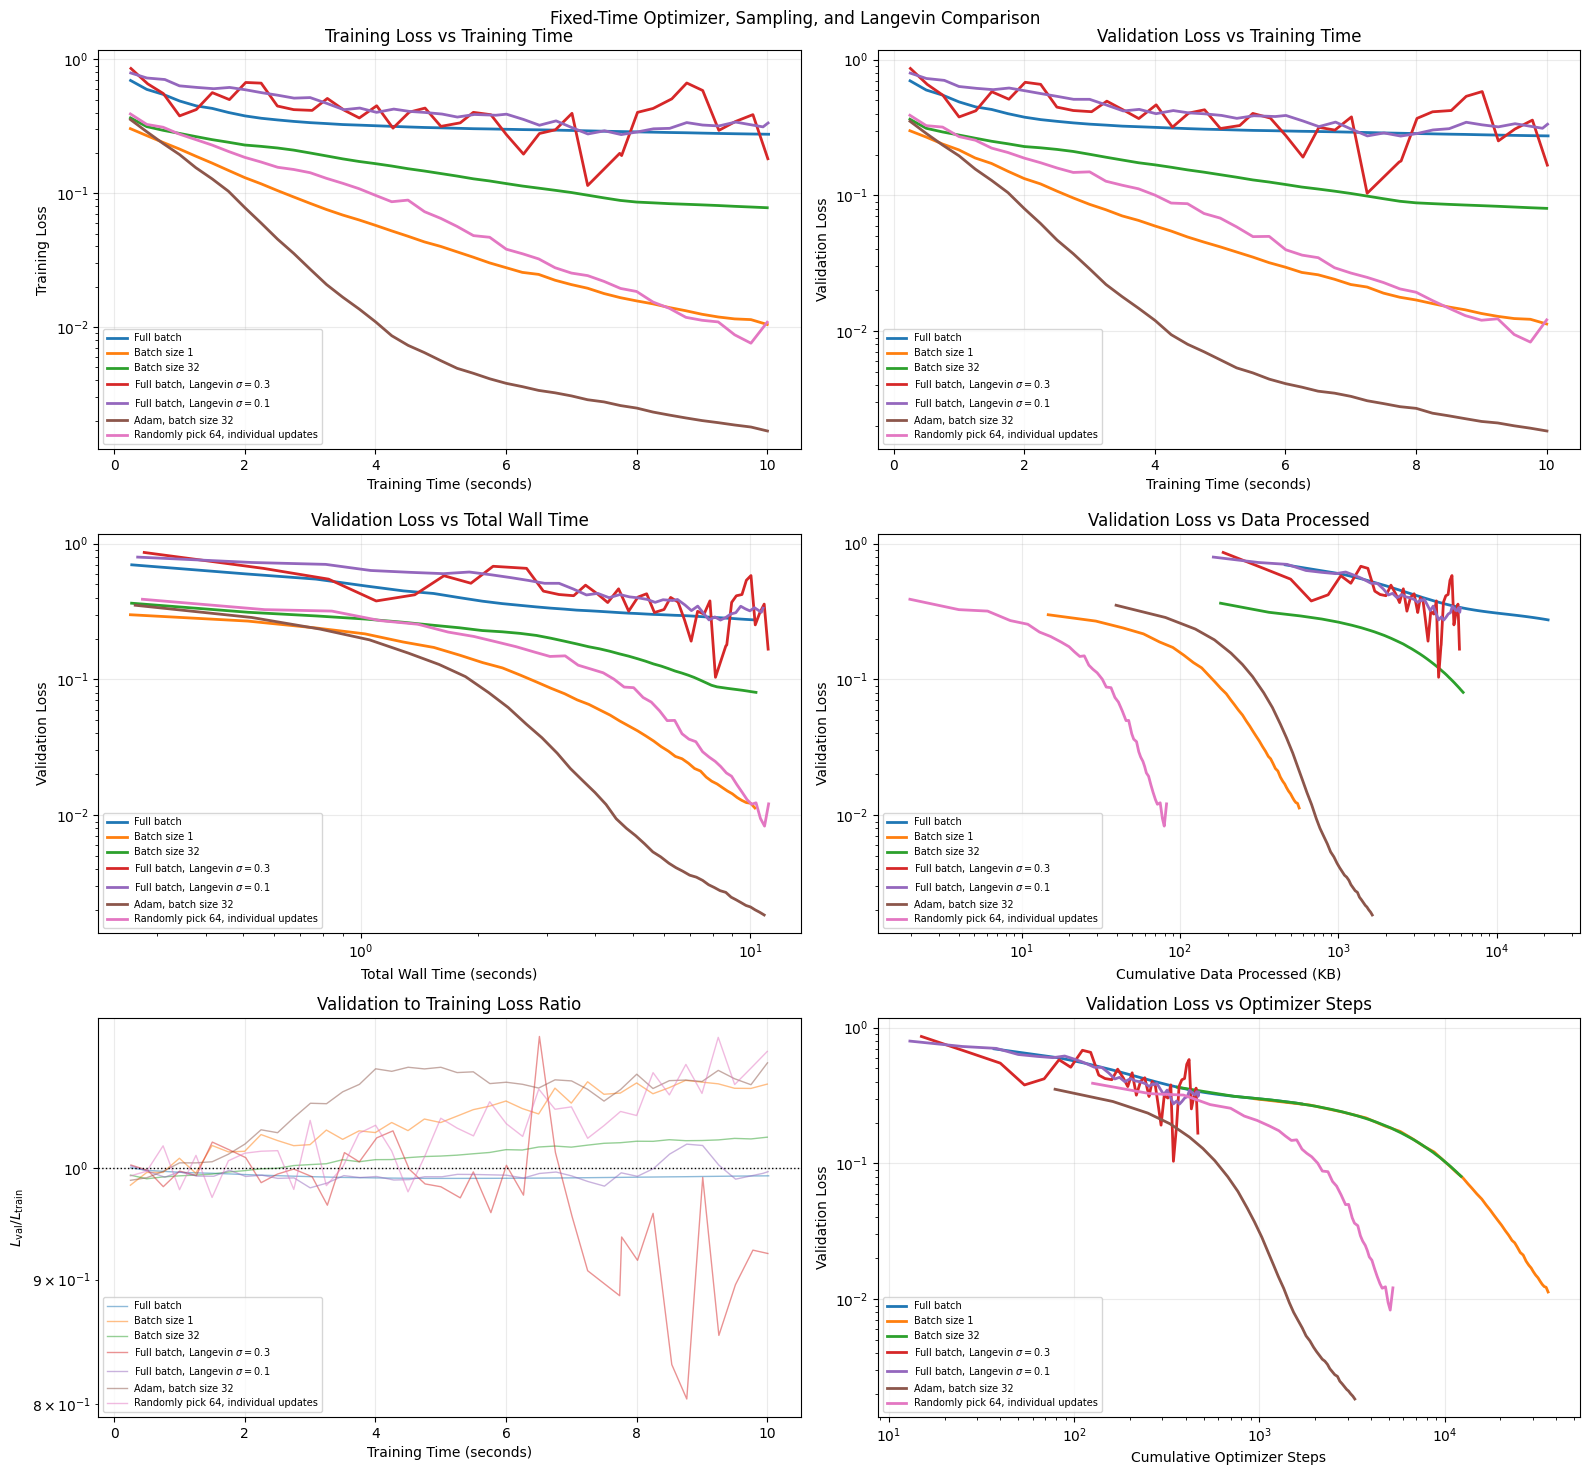

Final results:
Full batch                                   : test=0.296642, train_time=10.0212s, wall_time=10.2562s, steps=1691, data=21137.50 KB
Batch size 1                                 : test=0.008966, train_time=10.0002s, wall_time=10.2785s, steps=36232, data=566.12 KB
Batch size 32                                : test=0.081170, train_time=10.0002s, wall_time=10.3423s, steps=12294, data=6147.00 KB
Full batch, Langevin $\sigma=0.3$            : test=0.172419, train_time=10.0097s, wall_time=11.1128s, steps=466, data=5825.00 KB
Full batch, Langevin $\sigma=0.1$            : test=0.332056, train_time=10.0133s, wall_time=10.7801s, steps=472, data=5900.00 KB
Adam, batch size 32                          : test=0.001222, train_time=10.0038s, wall_time=10.8568s, steps=3278, data=1639.00 KB
Randomly pick 64, individual updates         : test=0.009090, train_time=10.0000s, wall_time=11.1436s, steps=5265, data=82.27 KB


In [38]:
import numpy as np
import matplotlib.pyplot as plt


runs = {
    "Full batch": (L_train1, L_val1, L_test1, M1),
    "Batch size 1": (L_train2, L_val2, L_test2, M2),
    f"Batch size {n_batch}": (L_train3, L_val3, L_test3, M3),
    r"Full batch, Langevin $\sigma=0.3$":
        (L_train4, L_val4, L_test4, M4),
    r"Full batch, Langevin $\sigma=0.1$":
        (L_train5, L_val5, L_test5, M5),
    f"Adam, batch size {n_batch}":
        (L_train6, L_val6, L_test6, M6),
    "Randomly pick 64, individual updates":
        (L_train7, L_val7, L_test7, M7),
}


fig, axes = plt.subplots(3, 2, figsize=(16, 15))

for label, (train_loss, val_loss, _, metrics) in runs.items():
    train_loss = np.asarray(train_loss)
    val_loss = np.asarray(val_loss)

    train_time = np.asarray(metrics["train_wall_s"])
    total_wall_time = np.asarray(metrics["wall_s"])
    data_kb = np.asarray(metrics["data_kb"])
    optimizer_steps = np.asarray(
        metrics["optimizer_steps"]
    )

    validation_training_ratio = np.divide(
        val_loss,
        train_loss,
        out=np.zeros_like(val_loss),
        where=train_loss > 0
    )

    axes[0, 0].plot(
        train_time,
        train_loss,
        label=label,
        linewidth=2
    )

    axes[0, 1].plot(
        train_time,
        val_loss,
        label=label,
        linewidth=2
    )

    axes[1, 0].plot(
        total_wall_time,
        val_loss,
        label=label,
        linewidth=2
    )

    axes[1, 1].plot(
        data_kb,
        val_loss,
        label=label,
        linewidth=2
    )

    axes[2, 0].plot(
        train_time,
        validation_training_ratio,
        label=label,
        linewidth=1,
        alpha=0.5
    )

    axes[2, 1].plot(
        optimizer_steps,
        val_loss,
        label=label,
        linewidth=2
    )


axes[0, 0].set_title("Training Loss vs Training Time")
axes[0, 1].set_title("Validation Loss vs Training Time")
axes[1, 0].set_title("Validation Loss vs Total Wall Time")
axes[1, 1].set_title("Validation Loss vs Data Processed")
axes[2, 0].set_title("Validation to Training Loss Ratio")
axes[2, 1].set_title("Validation Loss vs Optimizer Steps")


axes[0, 0].set_xlabel("Training Time (seconds)")
axes[0, 1].set_xlabel("Training Time (seconds)")
axes[1, 0].set_xlabel("Total Wall Time (seconds)")
axes[1, 1].set_xlabel(
    "Cumulative Data Processed (KB)"
)
axes[2, 0].set_xlabel("Training Time (seconds)")
axes[2, 1].set_xlabel(
    "Cumulative Optimizer Steps"
)


axes[0, 0].set_ylabel("Training Loss")
axes[0, 1].set_ylabel("Validation Loss")
axes[1, 0].set_ylabel("Validation Loss")
axes[1, 1].set_ylabel("Validation Loss")
axes[2, 0].set_ylabel(
    r"$L_{\mathrm{val}}/L_{\mathrm{train}}$"
)
axes[2, 1].set_ylabel("Validation Loss")


for ax in axes.flat:
    ax.set_yscale("log")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7)


# Logarithmic resource axes
axes[1, 0].set_xscale("log")
axes[1, 1].set_xscale("log")
axes[2, 1].set_xscale("log")


axes[2, 0].axhline(
    1,
    color="black",
    linestyle=":",
    linewidth=1
)


fig.suptitle(
    "Fixed-Time Optimizer, Sampling, and Langevin Comparison"
)

plt.tight_layout()
plt.show()


print("Final results:")

for label, (_, _, test_loss, metrics) in runs.items():
    print(
        f"{label:45s}: "
        f"test={test_loss:.6f}, "
        f"train_time={metrics['train_wall_s'][-1]:.4f}s, "
        f"wall_time={metrics['wall_s'][-1]:.4f}s, "
        f"steps={metrics['optimizer_steps'][-1]}, "
        f"data={metrics['data_kb'][-1]:.2f} KB"
    )


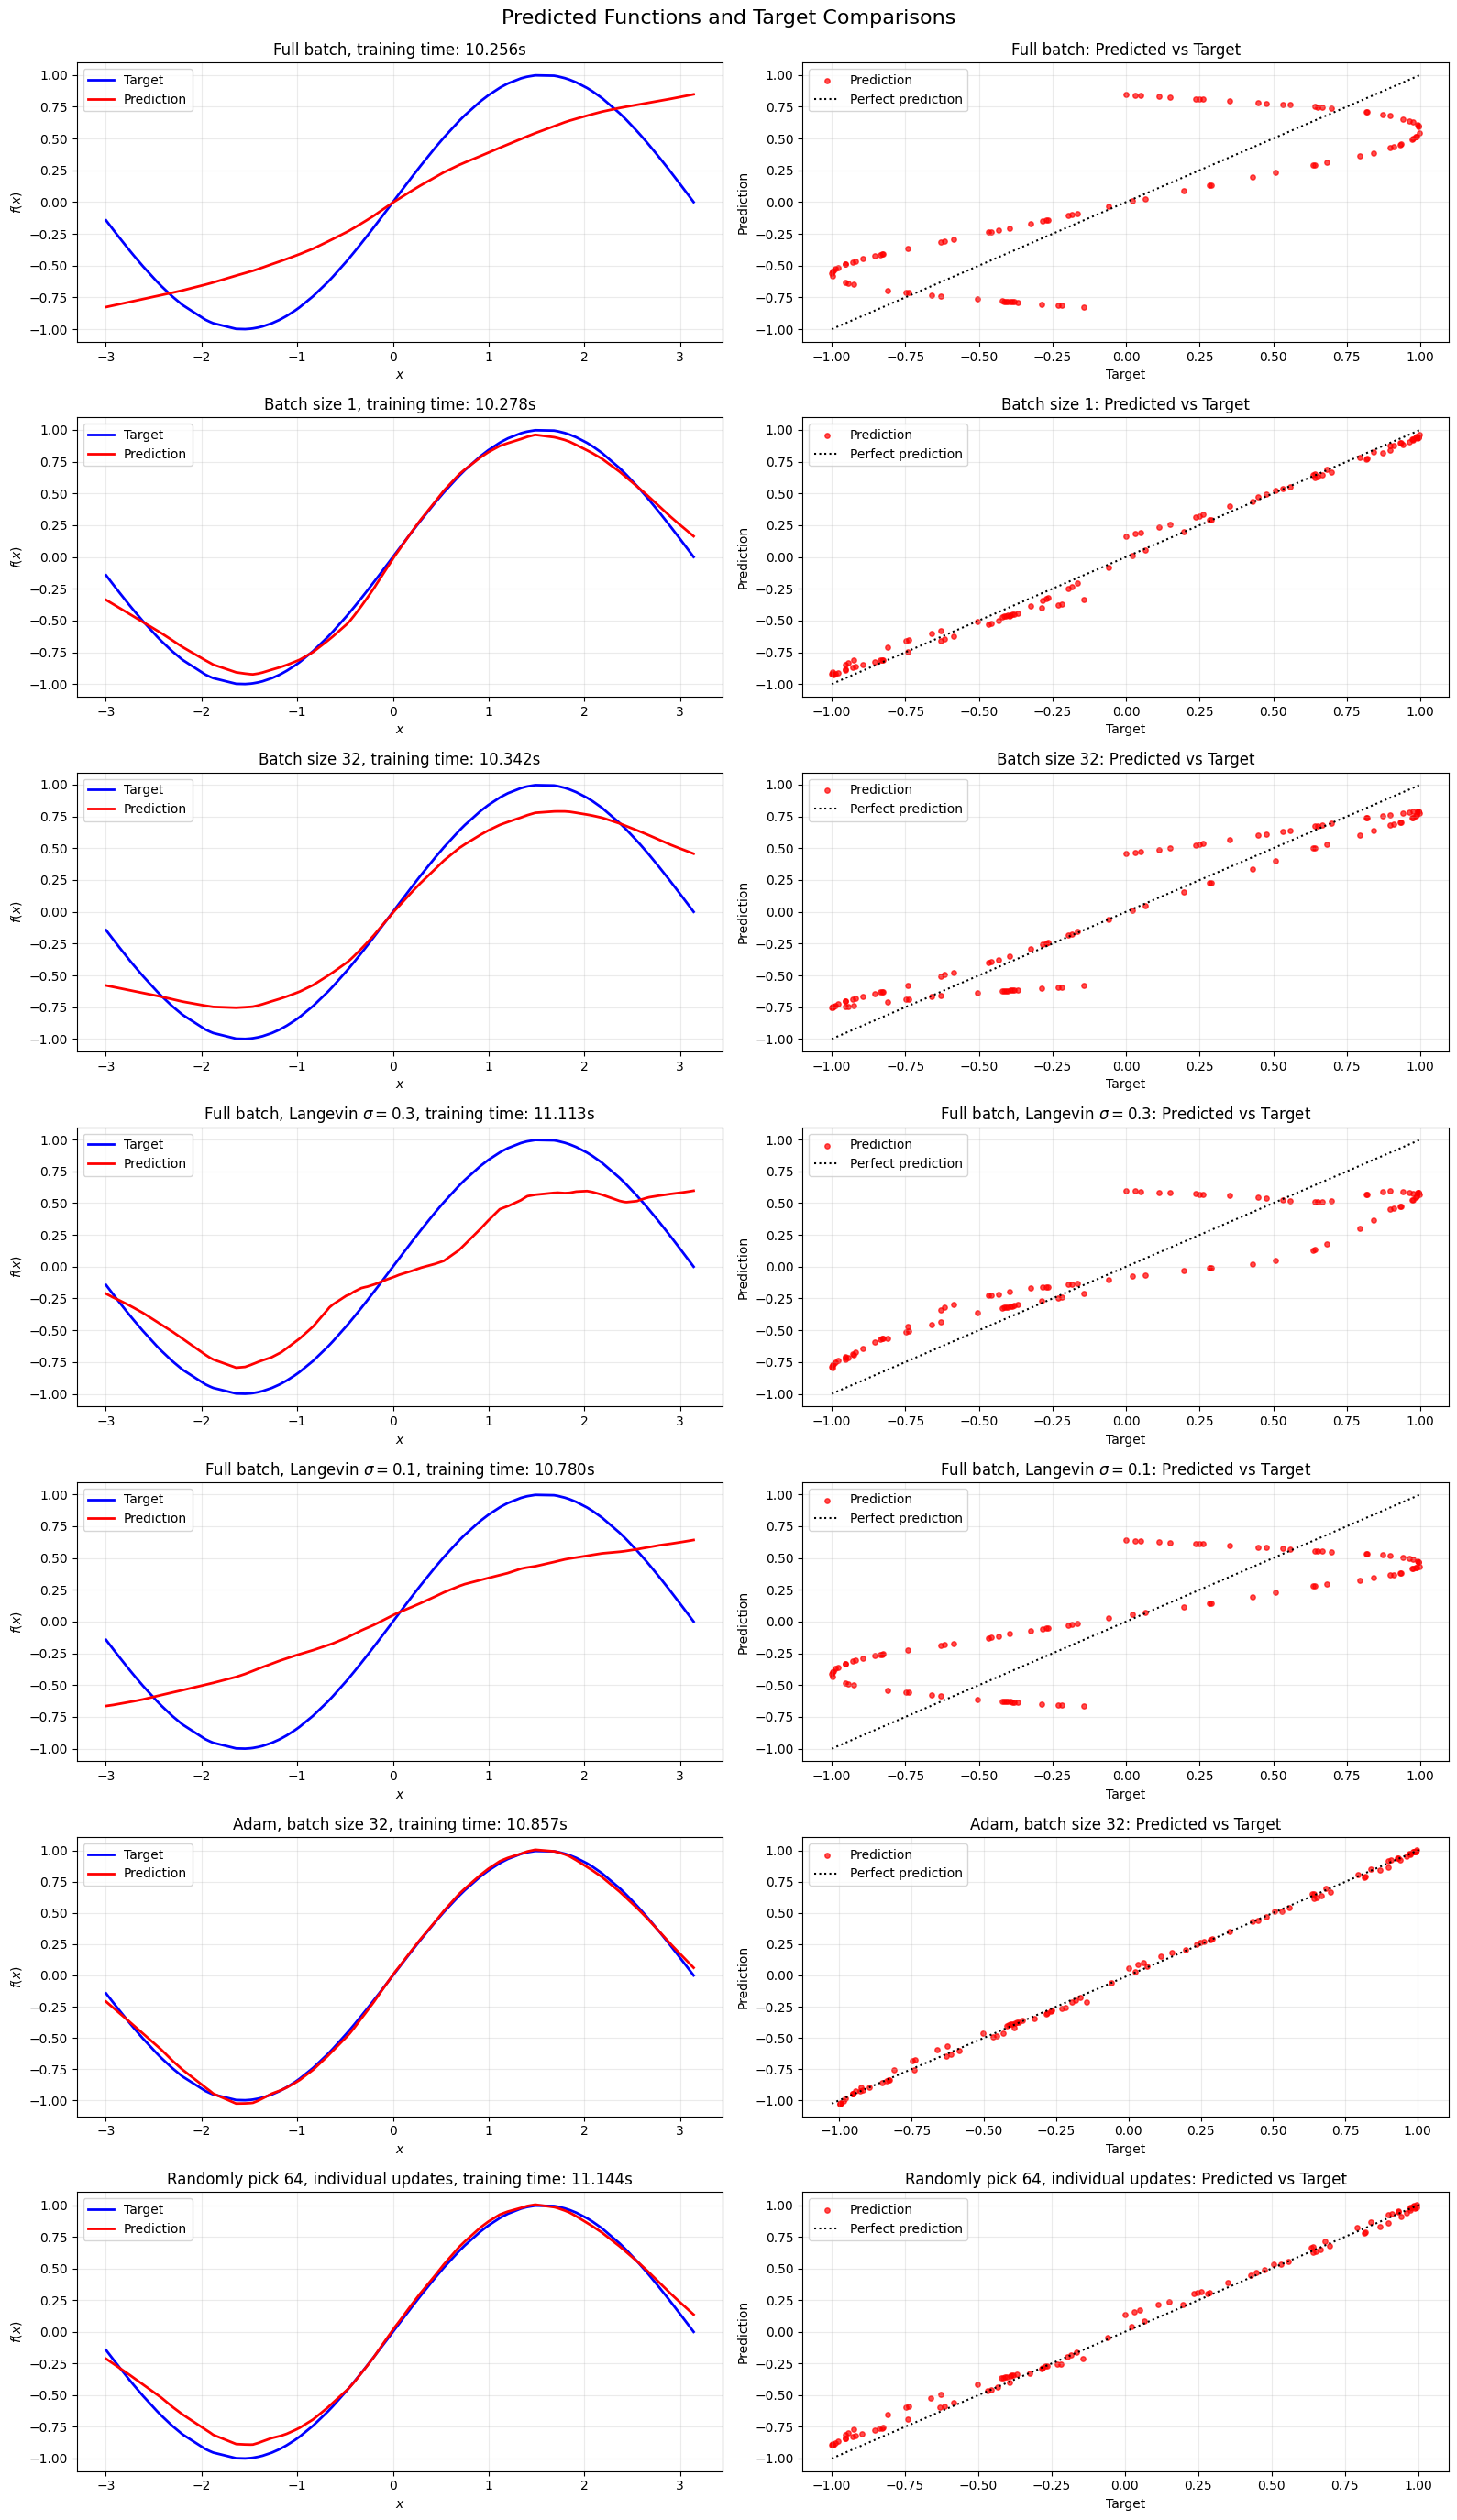

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import torch


methods = [
    ("Full batch", model1, M1),
    ("Batch size 1", model2, M2),
    (f"Batch size {n_batch}", model3, M3),
    (r"Full batch, Langevin $\sigma=0.3$", model4, M4),
    (r"Full batch, Langevin $\sigma=0.1$", model5, M5),
    (f"Adam, batch size {n_batch}", model6, M6),
    ("Randomly pick 64, individual updates", model7, M7),
]


# Return standardized test data to its original scale
x_original = x_test * x_std + x_mean
y_original = y_test * y_std + y_mean

x_np = x_original.detach().numpy().reshape(-1)
y_np = y_original.detach().numpy().reshape(-1)

sort_indices = np.argsort(x_np)
x_sorted = x_np[sort_indices]
y_sorted = y_np[sort_indices]


fig, axes = plt.subplots(
    7,
    2,
    figsize=(16, 28)
)

for row, (label, model, metrics) in enumerate(methods):
    model.eval()

    with torch.no_grad():
        prediction_standardized = model(x_test)
        prediction_original = (
            prediction_standardized * y_std + y_mean
        )

    prediction = (
        prediction_original
        .detach()
        .numpy()
        .reshape(-1)
    )

    prediction_sorted = prediction[sort_indices]
    training_time = metrics["wall_s"][-1]

    axes[row, 0].plot(
        x_sorted,
        y_sorted,
        color="blue",
        linewidth=2,
        label="Target"
    )

    axes[row, 0].plot(
        x_sorted,
        prediction_sorted,
        color="red",
        linewidth=2,
        label="Prediction"
    )

    axes[row, 0].set_title(
        f"{label}, training time: {training_time:.3f}s"
    )
    axes[row, 0].set_xlabel(r"$x$")
    axes[row, 0].set_ylabel(r"$f(x)$")
    axes[row, 0].grid(alpha=0.25)
    axes[row, 0].legend()

    axes[row, 1].scatter(
        y_np,
        prediction,
        color="red",
        s=15,
        alpha=0.7,
        label="Prediction"
    )

    lower = min(y_np.min(), prediction.min())
    upper = max(y_np.max(), prediction.max())

    axes[row, 1].plot(
        [lower, upper],
        [lower, upper],
        color="black",
        linestyle=":",
        linewidth=1.5,
        label="Perfect prediction"
    )

    axes[row, 1].set_title(
        f"{label}: Predicted vs Target"
    )
    axes[row, 1].set_xlabel("Target")
    axes[row, 1].set_ylabel("Prediction")
    axes[row, 1].grid(alpha=0.25)
    axes[row, 1].legend()


fig.suptitle(
    "Predicted Functions and Target Comparisons",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

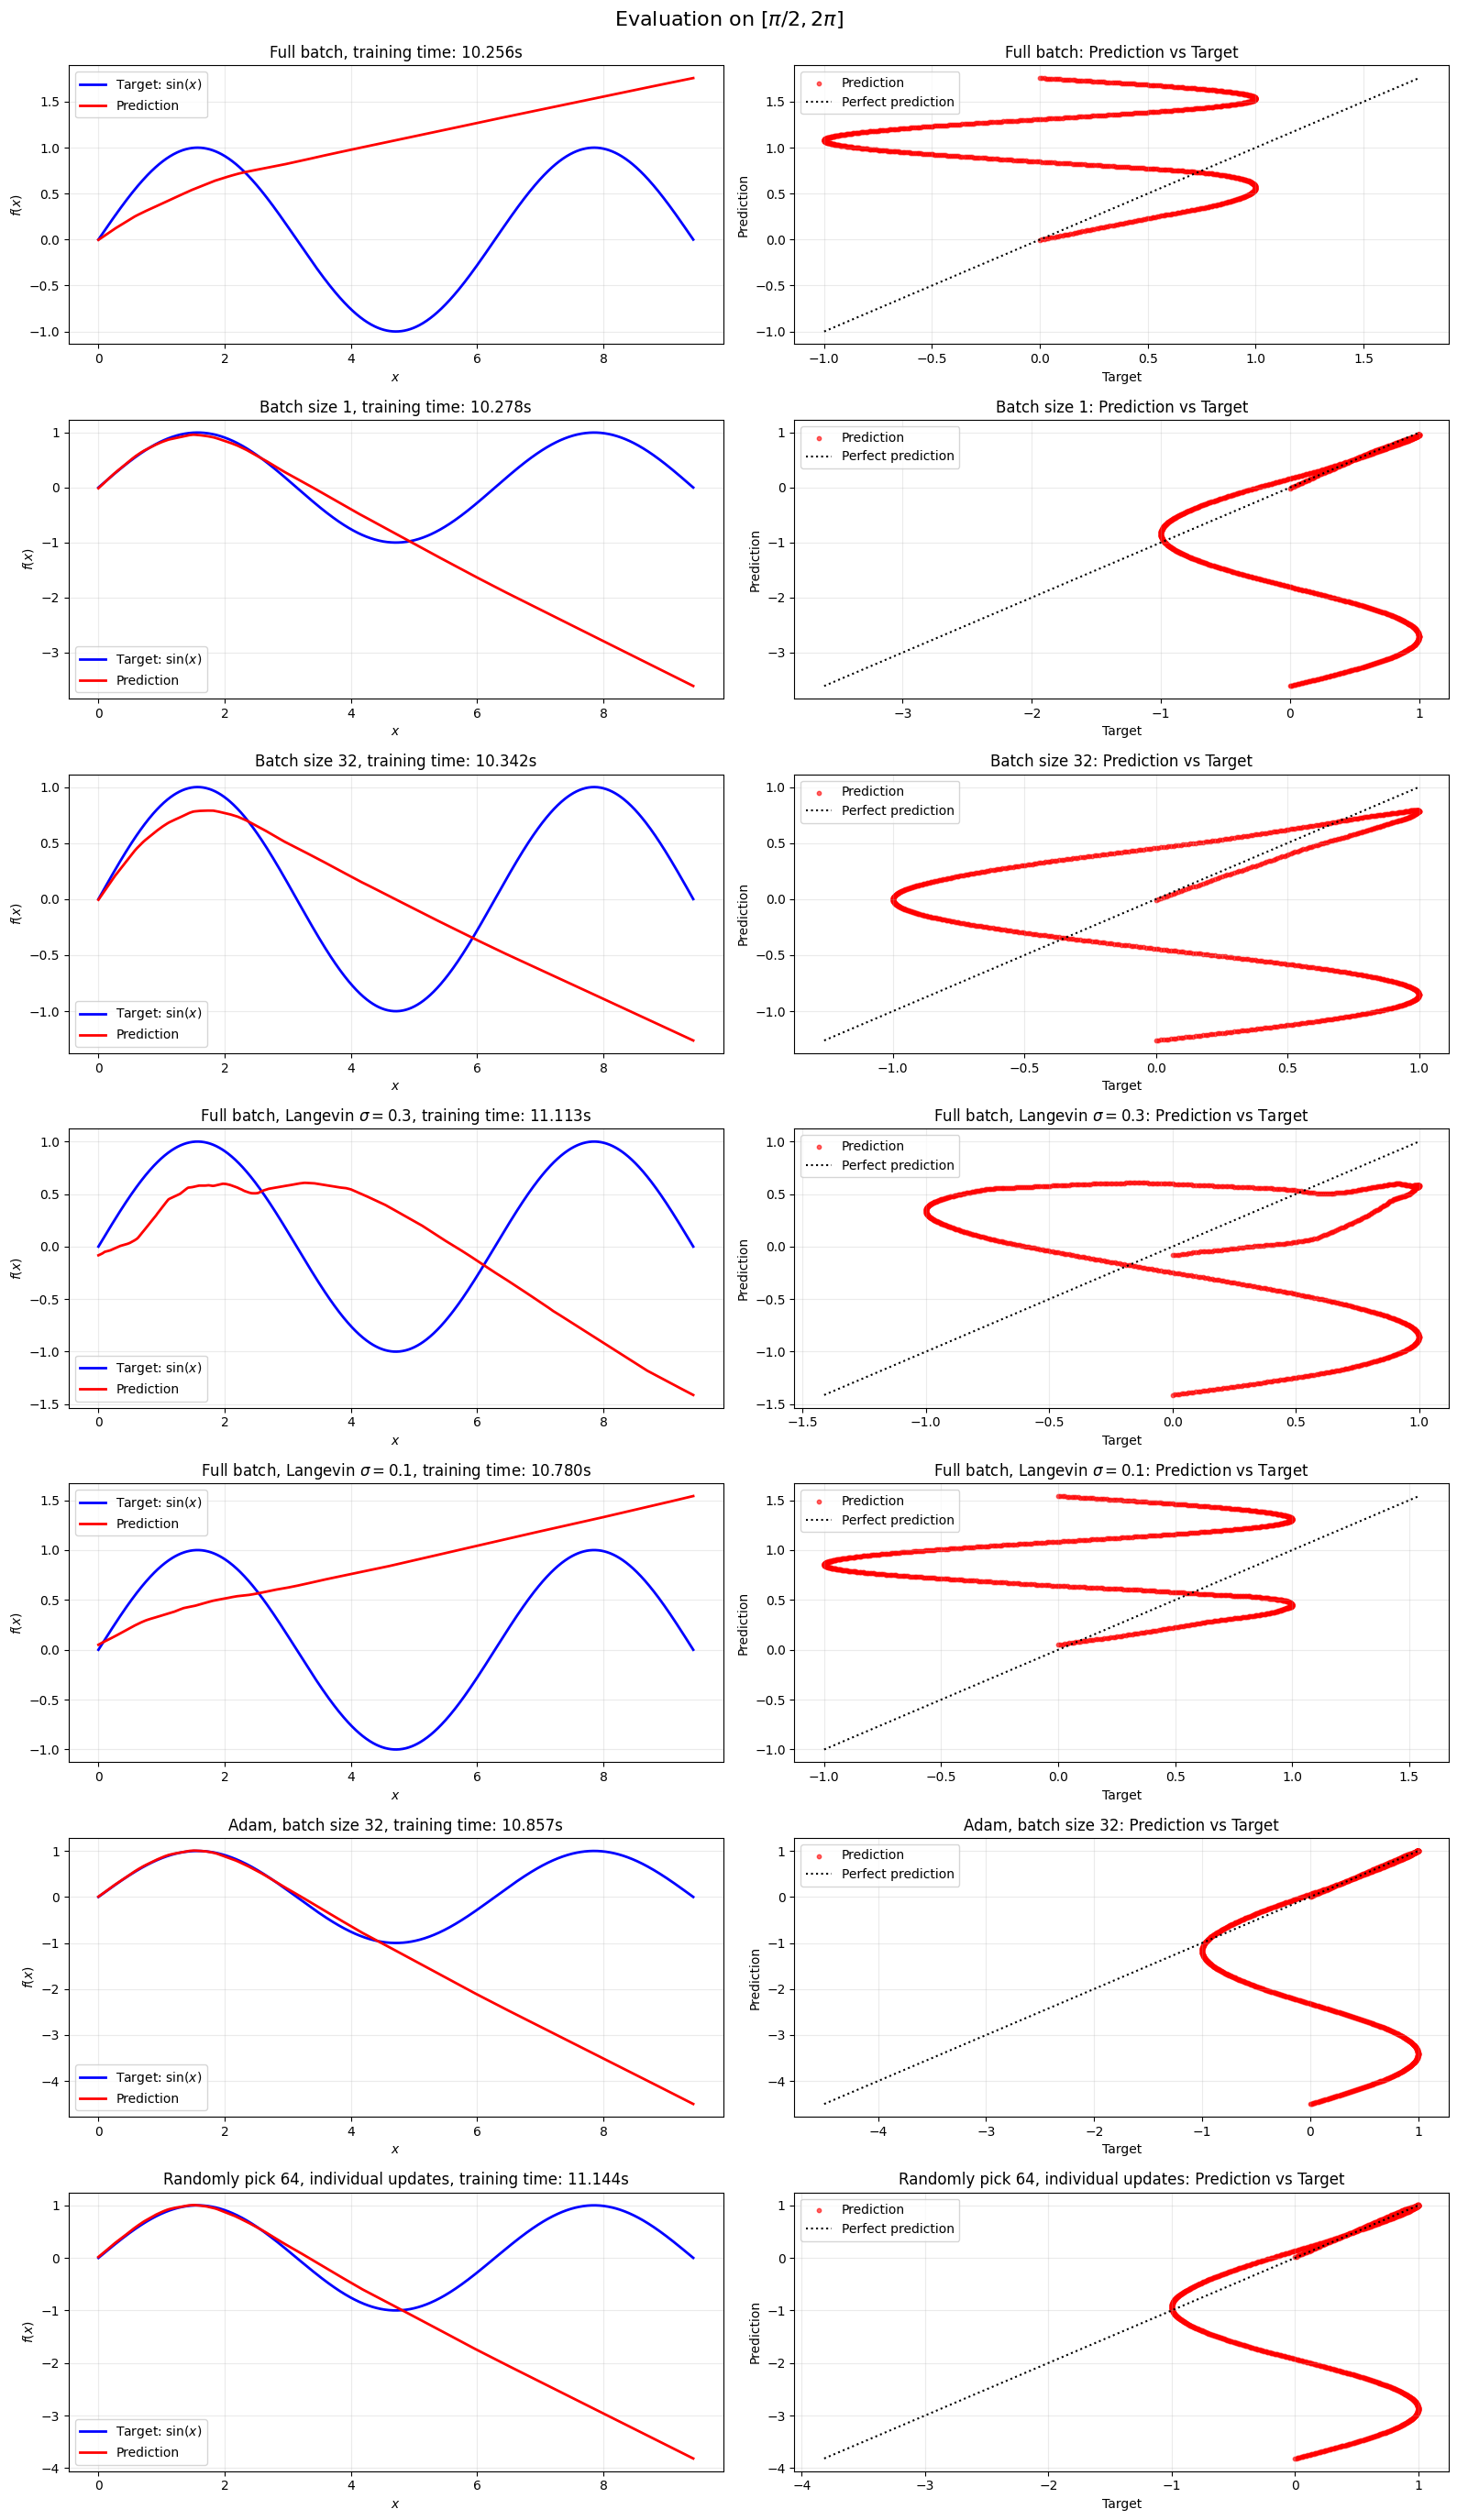

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import torch


# Original-scale evaluation grid on [pi/2, 2pi]
x_test_test_original = torch.linspace(
    0,
    3 * np.pi,
    1000,
    dtype=x_train.dtype
).reshape(-1, 1)

y_test_test_original = torch.sin(x_test_test_original)


# Standardize inputs using training statistics
x_test_test = (
    x_test_test_original - x_mean
) / x_std


methods = [
    ("Full batch", model1, M1),
    ("Batch size 1", model2, M2),
    (f"Batch size {n_batch}", model3, M3),
    (r"Full batch, Langevin $\sigma=0.3$", model4, M4),
    (r"Full batch, Langevin $\sigma=0.1$", model5, M5),
    (f"Adam, batch size {n_batch}", model6, M6),
    ("Randomly pick 64, individual updates", model7, M7),
]


x_np = (
    x_test_test_original
    .detach()
    .numpy()
    .reshape(-1)
)

y_np = (
    y_test_test_original
    .detach()
    .numpy()
    .reshape(-1)
)


fig, axes = plt.subplots(
    7,
    2,
    figsize=(16, 28)
)

for row, (label, model, metrics) in enumerate(methods):
    model.eval()

    with torch.no_grad():
        prediction_standardized = model(x_test_test)

        prediction_original = (
            prediction_standardized * y_std + y_mean
        )

    prediction = (
        prediction_original
        .detach()
        .numpy()
        .reshape(-1)
    )

    training_time = metrics["wall_s"][-1]

    axes[row, 0].plot(
        x_np,
        y_np,
        color="blue",
        linewidth=2,
        label=r"Target: $\sin(x)$"
    )

    axes[row, 0].plot(
        x_np,
        prediction,
        color="red",
        linewidth=2,
        label="Prediction"
    )

    axes[row, 0].set_title(
        f"{label}, training time: {training_time:.3f}s"
    )
    axes[row, 0].set_xlabel(r"$x$")
    axes[row, 0].set_ylabel(r"$f(x)$")
    axes[row, 0].grid(alpha=0.25)
    axes[row, 0].legend()

    axes[row, 1].scatter(
        y_np,
        prediction,
        color="red",
        s=10,
        alpha=0.6,
        label="Prediction"
    )

    lower = min(y_np.min(), prediction.min())
    upper = max(y_np.max(), prediction.max())

    axes[row, 1].plot(
        [lower, upper],
        [lower, upper],
        color="black",
        linestyle=":",
        linewidth=1.5,
        label="Perfect prediction"
    )

    axes[row, 1].set_title(
        f"{label}: Prediction vs Target"
    )
    axes[row, 1].set_xlabel("Target")
    axes[row, 1].set_ylabel("Prediction")
    axes[row, 1].grid(alpha=0.25)
    axes[row, 1].legend()


fig.suptitle(
    r"Evaluation on $[\pi/2,2\pi]$",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()